In [1]:
import pandas as pd
import numpy as np
import re
import uproot
from scipy.integrate import quad


r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=2.4
# R_ue_high=-5.0
log10TeV_low=3.7
log10TeV_high=4.3


def load_allweight_model():
    
    r_low=300
    r_high=450
    theta_low=0
    theta_high=35 / 180.0 * np.pi

    Eage_low=0.8
    Eage_high=2.4
    # R_ue_high=-5.0
    log10TeV_low=3.7
    log10TeV_high=4.3

    def open_file(file_name):
        with uproot.open(file_name) as file:
            tree = file["Rec"]
            branches_to_read = ["E", "theta","phi","corex","corey","rec_x","rec_y","rec_theta","rec_phi","rec_Eage","Redge","NpE3","NuM1","NuM2","NuM3","NuW3",
                                "weightGaisser","weightHorandol","weightGSF"]
            df = tree.arrays(branches_to_read, library="pd")
            all_weights_gaisser = df['weightGaisser'].sum()
            all_weights_horandel = df['weightHorandol'].sum()
            all_weights_gsf = df['weightGSF'].sum()
            print(file_name)
            print("     Entries:", tree.num_entries)
            print("     Total weights Gaisser:", all_weights_gaisser)
            print("     Total weights Horandel:", all_weights_horandel)
            print("     Total weights GSF:", all_weights_gsf)

            rec_Eage=df['rec_Eage'].values
            rec_theta=df['rec_theta'].values
            NuW3=df['NuW3'].values
            rec_x=df['rec_x'].values
            rec_y=df['rec_y'].values
            r=np.sqrt(rec_x**2+rec_y**2)
            df['rec_r']=r
            cuts_indices = (rec_Eage > Eage_low) & (rec_Eage < Eage_high) & \
                            (r > r_low) & (r < r_high) & \
                            (rec_theta > theta_low) & (rec_theta < theta_high) & \
                            (NuW3 > 0)
            df_cut = df[cuts_indices].copy() 
            
            df_cut["R_ue"]=np.log10((1e-4+df_cut["NuM1"])/(df_cut["NpE3"]+1))
            print(f"     Entries after cut: {df_cut.shape[0]}")
            
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightGaisser'], histtype='step', label='Gaisser', color='blue')
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightHorandol'], histtype='step', label='Horandel', color='red')
            # plt.hist(np.log10(df_cut['E']), bins=50, range=(4, 8.5), weights=df_cut['weightGSF'], histtype='step', label='GSF', color='green')
            # plt.xlabel('log10(Energy/1e8 GeV)')
            # plt.ylabel('Weighted Counts')
            # plt.title('Energy Distribution after Cuts')
            # plt.legend()
            # plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures
            # plt.show()
            del df
            return df_cut
        

    def energy_correction(df: pd.DataFrame):
        import json
        
        # 加载线性参数
        with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
            lp = json.load(f)
        intercept  = lp["intercept"]
        coef_NuW3  = lp["coef"][0]
        coef_theta = lp["coef"][1]

        theta      = df["rec_theta"].values
        log10_NuW3 = np.log10(df["NuW3"].values)
        
        feature_data = np.column_stack((log10_NuW3, theta))
        
        # 线性基线 + XGBoost残差
        linear_pred  = intercept + coef_NuW3 * log10_NuW3 + coef_theta * theta
        xgb_residual = model.predict(feature_data)
        corrected_energy = linear_pred + xgb_residual  # log10(E/1e8)
        
        df["recE"] = corrected_energy
        
        df_new = df[(df["recE"] > log10TeV_low) & (df["recE"] < log10TeV_high)]
        print(f" cut weight Gaisser sum: {df_new['weightGaisser'].sum()}")
        print(f" cut weight Horandel sum: {df_new['weightHorandol'].sum()}")
        print(f" cut weight GSF sum: {df_new['weightGSF'].sum()}")
        del df
        return df_new


    from xgboost import XGBRegressor
    model = XGBRegressor()
    model._estimator_type = "regressor"
    model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")

    proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root")
    # proton_df_QF = open_file("/data/home/zzh/data/Dataset_Filted/CosmicRay/Proton_1.0e14_1.0e17_RecTNtuple_Weights.root")
    proton_df_QF = energy_correction(proton_df_QF)
    QF_allweights_gaisser=proton_df_QF['weightGaisser'].sum()
    QF_allweights_horandel=proton_df_QF['weightHorandol'].sum()
    

   

    return QF_allweights_gaisser,QF_allweights_horandel, proton_df_QF

QF_allweights_gaisser, QF_allweights_horandel, proton_df_QF = load_allweight_model()


def parse_sim_log(txt_filepath):
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
        """
        计算带有膝区截断的保守 Gaisser 质子流强
        """
        # PHI_0 = 0.096
        # GAMMA_1 = 2.7     # 膝区前的能谱指数
        # GAMMA_2 = 3.3     # 膝区后的能谱指数 (你可以根据 LHAASO 内部的推荐值微调，通常在 3.1~3.4 之间)
        # E_C = 4000.0      # 质子膝区位置 (4000 TeV = 4 PeV)
        
        # # return PHI_0 * (E_TeV ** -GAMMA_1)
        
        
        # # --------------------------------------------------------
        # if E_TeV < E_C:
        #     return PHI_0 * (E_TeV ** -GAMMA_1)
        # else:
        #     # 为了保证在 E_C 处连续，需要乘上一个平滑系数 E_C^(GAMMA_2 - GAMMA_1)
        #     smooth_factor = E_C ** (GAMMA_2 - GAMMA_1)
        #     return PHI_0 * smooth_factor * (E_TeV ** -GAMMA_2)
        
        
        # --------------------------------------------------------
        # E_GeV = E_TeV * 1000.0
        # # Gaisser H4a 参数表: a_i 单位是 [m^-2 s^-1 sr^-1 GeV^-1]
        # # 族群 1: 超新星遗迹 (截断在 4 PeV)
        # a1, gamma1, R1 = 7860.0, 2.66, 4.0e6  
        # # 族群 2: 银河系高能源 (截断在 30 PeV)
        # a2, gamma2, R2 = 20.0,   2.40, 30.0e6 
        # # 族群 3: 河外源 (截断在 2 EeV)
        # a3, gamma3, R3 = 1.7,    2.40, 2.0e9  

        # # 累加三个族群的流强
        # flux_GeV = (
        #     a1 * (E_GeV ** -gamma1) * np.exp(-E_GeV / R1) +
        #     a2 * (E_GeV ** -gamma2) * np.exp(-E_GeV / R2) +
        #     a3 * (E_GeV ** -gamma3) * np.exp(-E_GeV / R3)
        # )

        # # 转换回 TeV^-1 (因为主程序计算截面用的是 TeV)
        # flux_TeV = flux_GeV * 1000.0
        # return flux_TeV
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 35.0   
    R_MIN, R_MAX = 300.0, 450.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 30.0   
    R_MIN, R_MAX = 300.0, 450.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df


from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")


def filter_dataset_optimized(npz_file, output_file=None, mc=True, R_mean_cut=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    elif radius_cut is True:
        r_low=300
        r_high=450  
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        param_names = data["param_names"]
        print(len(param_names))
        if len(param_names) % 30 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:30])
        elif len(param_names) % 32 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:32])
        else:
            raise ValueError(f"Unexpected number of parameters: {len(param_names)}. Expected 30 or 32.")
        
        
    else:
        params_df = pd.read_csv(npz_file)
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
    print("--------------------------------------------------")

    
    
    return params_df[current_mask].copy(), params_df


def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 650**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/5400/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df


def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Gaisser"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def give_bkg_mc_weights_horandel(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_Horandel"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['horandel_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['horandel_weight']=pr_df['horandel_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['horandel_weight'].sum()} ======")
    return pr_df


def give_bkg_mc_weights_GSF(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight_GSF"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    pr_df['GSF_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['GSF_weight']=pr_df['GSF_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['GSF_weight'].sum()} ======")
    return pr_df




def parse_sim_log(txt_filepath):
    """
    解析 .out.txt，提取每个能段实际处理的事例总数 N_bin
    返回格式: {(E_min_eV, E_max_eV): N_total}
    """
    bins_count = {}
    current_bin = None
    
    with open(txt_filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # 捕获能段: Processing: [2.5e15_4.0e15]
            m_bin = re.search(r'Processing:\s*\[([0-9\.e]+)_([0-9\.e]+)\]', line)
            if m_bin:
                current_bin = (float(m_bin.group(1)), float(m_bin.group(2)))
                bins_count[current_bin] = 0
                continue
            
            # 捕获处理数: RUN: run001 | Found: 1000 | Processing: 1000
            m_proc = re.search(r'Processing:\s*(\d+)', line)
            if m_proc and current_bin:
                bins_count[current_bin] += int(m_proc.group(1))
    
    
    # plt.bar([f"{e_min/1e9:.1e}-{e_max/1e9:.1e} GeV" for (e_min, e_max) in bins_count.keys()], bins_count.values())
    # plt.xlabel("Energy Bin (GeV)")
    # plt.ylabel("Total Processed Events")
    # plt.title("Total Processed Events per Energy Bin from Log File")
    # plt.xticks(rotation=45)
    # plt.tight_layout()
    # plt.show()
    return bins_count


def calculate_weights(df, log_filepath, root_filepath, dlogE=0.01):
    """
    完全参照 C++ 逻辑：
    在 (FineEnergyBin, ZenithBin) 的二维网格中，分别计算 EventTrue 和 EventSim 并相除
    """
    def gaisser_proton_flux_with_knee(E_TeV, z=0):
        """
        LHAASO 官方 Gaisser H3a 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 参数矩阵 aij[3][5]
        aij = [
            [7860, 3550, 2200, 1430, 2120],
            [20,   20,   13.4, 13.4, 13.4],
            [1.7,  1.7,  1.14, 1.14, 1.14]
        ]
        # 积分谱指数矩阵 rij[3][5] (代码中参与计算为 -rij - 1)
        rij = [
            [1.66, 1.58, 1.63, 1.67, 1.63],
            [1.4,  1.4,  1.4,  1.4,  1.4],
            [1.4,  1.4,  1.4,  1.4,  1.4]
        ]
        # 截断刚度 rc (GeV)
        rc = [4e6, 30e6, 2e9] 
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        flux_GeV = 0.0
        for ii in range(3):
            term1 = aij[ii][z]
            term2 = energy_GeV ** (-rij[ii][z] - 1.0)
            term3 = np.exp(-energy_GeV / (Ze[z] * rc[ii]))
            flux_GeV += term1 * term2 * term3
            
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0 
        return flux_TeV
       
    
    sim_bins = parse_sim_log(log_filepath)
    print(sim_bins)
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260, 480.0
    # R_MIN, R_MAX = 0.0, 280.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    # sum_h2_gen_total = np.sum(h2_vals)
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    # prob_theta_sim_total = h2_vals / sum_h2_gen_total
    # prob_theta_sim[valid_zen_mask] = prob_theta_sim_total[valid_zen_mask]
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用数值积分完美处理带截断的 Gaisser 公式
            flux_integral_true = quad(gaisser_proton_flux_with_knee, E_low, E_up)[0]
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['gaisser_weight'] = weights_rate
    return df


def calculate_weights_horandel(df, log_filepath, root_filepath, dlogE=0.01):
    """
    使用 Hörandel 模型数值积分的 2D Grid 权重计算
    """
    
    def horandel_proton_flux(E_TeV, z=0):
        """
        计算 Hörandel 模型的质子微分流强
        单位: [m^-2 s^-1 sr^-1 TeV^-1]
        参数参考 Hörandel 2003 经典参数 (你可以替换为你 C++ 中的具体数值)
        """
        # PHI_0 = 0.0873         # 绝对流强归一化系数
        # GAMMA = 2.71           # 谱指数
        # E_C = 4490.0           # 截断能量 (Knee) 对于质子大概在 4.5 PeV = 4490 TeV
        # EPSILON = 1.9          # 平滑过渡参数
        # DELTA_GAMMA = 2.1      # 截断前后的谱指数差 (截断后变陡)
        
        # flux = PHI_0 * (E_TeV ** -GAMMA) * (1.0 + (E_TeV / E_C)**EPSILON)**(-DELTA_GAMMA / EPSILON)
        # return flux
        """
        LHAASO 官方 Hörandel 模型 (翻译自官方 C++)
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        
        # 1 GeV 处的归一化流强
        FluxGeV = [1.178e4, 4.749e3, 3.141e3, 2.011e3, 1.201e3]
        # Hörandel 谱指数
        Alpha = [-2.71, -2.64, -2.68, -2.69, -2.59]
        # 电荷数 Z
        Ze = [1, 2, 7, 13, 26]
        
        Ep = 4.49e6  # 质子膝区位置 (GeV)
        ec = 1.90    # 平滑度参数
        da = 2.1     # 截断后谱指数的变化量
        
        term1 = energy_GeV ** Alpha[z]
        term2 = (1.0 + (energy_GeV / (Ep * Ze[z])) ** ec) ** (-da / ec)
        
        flux_GeV = term1 * term2 * FluxGeV[z]
        
        # 将 GeV^-1 转为 TeV^-1 以适配主程序的积分逻辑
        flux_TeV = flux_GeV * 1000.0
        return flux_TeV
    
    
    
    sim_bins = parse_sim_log(log_filepath)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    # ====== 核心物理参数 ======
    THETA_MAX_GEN = 40.5
    R_MIN, R_MAX = 260, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2) # S_EFF
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       # CORSIKA 生成谱指数
    
    # ====== 预处理：Zenith 维度的概率与中心值 ======
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    # 算 cos(theta) 需要用弧度制的 bin center
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    # ====== 准备 DataFrame 映射 ======
    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  # 确保 trueE 是数值类型
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')  # 确保 theta 是数值类型
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180 / np.pi 
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        
        # 预计算：模拟能谱 (E^-2) 的大能段总积分
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        # -------------------------------------------------------------
        # 二维网格循环 
        # -------------------------------------------------------------
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # A. 计算该能段内的物理流强积分 (Hörandel 模型的数值积分)
            # 完美替代 C++ 中的 IntegrateHorandel(E_low, E_up)
            # quad 返回两个值：积分结果 和 误差估计，我们取第一个 [0]
            flux_integral_true = quad(horandel_proton_flux, E_low, E_up)[0]
            
            # B. 计算该能段内的模拟流强积分并求概率 P(E)
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                
                # --- 1. 计算 True Events (Hörandel 预期 Hz) ---
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                
                # --- 2. 计算 Sim Events (模拟预期事件数) ---
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                # --- 3. 计算权重 ---
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['horandel_weight'] = weights_rate
    return df


def calculate_weights_gsf(df, log_filepath, root_filepath, dlogE=0.01):
    """
    参照 C++ 逻辑：
    在二维网格中，使用 GSF 数据驱动模型计算 EventTrue 并相除得到权重
    """
    
    # ==========================================
    # 1. 预加载 GSF 数据表 (仅执行一次)
    # ==========================================
    gsf_table_path = "/data/home/zzh/data/Dataset_Filted/Simulation/gsf_data_table.txt"
    try:
        # loadtxt 会直接生成一个 29 x 1000 的 numpy 2D 数组
        gsf_data = np.loadtxt(gsf_table_path).T
    except Exception as e:
        raise RuntimeError(f"[ERROR] 无法读取 GSF 数据表 {gsf_table_path}: {e}")

    def gsf_flux_interp(E_TeV, z=0):
        """
        GSF 模型流强插值函数
        z (元素索引): 0=P, 1=He, 2=CNO, 3=MgAlSi, 4=Fe
        """
        energy_GeV = E_TeV * 1000.0
        energy_nodes = gsf_data[0] # 第 0 行是能量网格
        
        # 能量超限保护
        if energy_GeV < energy_nodes[0] or energy_GeV > energy_nodes[-1]:
            return 0.0
            
        # 根据 Z 提取对应的流量行 (与 C++ 逻辑严格对齐)
        if z == 0:
            y_nodes = gsf_data[1]
        elif z == 1:
            y_nodes = gsf_data[2]
        elif z == 2:   # CNO
            y_nodes = gsf_data[6] + gsf_data[7] + gsf_data[8]
        elif z == 3:   # MgAlSi
            y_nodes = gsf_data[12] + gsf_data[13] + gsf_data[14]
        elif z == 4:   # Fe
            y_nodes = gsf_data[26]
        else:
            return 0.0
            
        # 核心：使用 numpy 原生的一维线性插值，速度极快
        flux_GeV = np.interp(energy_GeV, energy_nodes, y_nodes)
        
        # 将 GeV^-1 转为 TeV^-1 以适配外层的定积分
        return flux_GeV * 1000.0
       
    # ==========================================
    # 2. 准备常规的日志与 ROOT 解析
    # ==========================================
    sim_bins = parse_sim_log(log_filepath)
    # print(sim_bins)
    
    with uproot.open(root_filepath) as f:
        h1 = f["h1"] 
        h2 = f["h2"] 
        zen_edges = h1.axis().edges()
        h1_vals = h1.values()
        h2_vals = h2.values()
        
    THETA_MAX_GEN = 40.5   
    R_MIN, R_MAX = 260.0, 480.0
    A_GEN = np.pi * (R_MAX**2 - R_MIN**2)
    T_DAY = 86400.0        
    SIM_INDEX = -2.0       
    
   
    valid_zen_mask = zen_edges[:-1] < THETA_MAX_GEN
    sum_h2_gen = np.sum(h2_vals[valid_zen_mask])
    prob_theta_sim = np.zeros_like(h2_vals)
    prob_theta_sim[valid_zen_mask] = h2_vals[valid_zen_mask] / sum_h2_gen
    
    zen_centers = (zen_edges[:-1] + zen_edges[1:]) / 2.0
    cos_theta_centers = np.cos(np.radians(zen_centers))

    df['trueE'] = pd.to_numeric(df['trueE'], errors='coerce')  
    df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
    trueE_GeV = df['trueE'].values
    trueE_TeV = trueE_GeV / 1000.0
    theta_vals = df['theta'].values * 180.0 / np.pi
    
    zen_indices = np.digitize(theta_vals, zen_edges) - 1
    zen_indices = np.clip(zen_indices, 0, len(h1_vals)-1)
    
    weights_rate = np.zeros(len(df))
    
    # ==========================================
    # 3. 2D 网格权重核心计算
    # ==========================================
    for (e_min_eV, e_max_eV), n_bin in sim_bins.items():
        if n_bin == 0: continue
            
        e_min_TeV = (e_min_eV / 1e9) / 1000.0
        e_max_TeV = (e_max_eV / 1e9) / 1000.0
        
        mask_chunk = (trueE_TeV >= e_min_TeV * 0.999) & (trueE_TeV <= e_max_TeV * 1.001)
        if not np.any(mask_chunk): continue
            
        logE_min, logE_max = np.log10(e_min_TeV), np.log10(e_max_TeV)
        sim_flux_integral_total = (e_max_TeV**(SIM_INDEX + 1.0) - e_min_TeV**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)

        num_fine_bins = int(np.ceil((logE_max - logE_min) / dlogE))
        fine_logE_edges = np.linspace(logE_min, logE_max, num_fine_bins + 1)
        
        logE_chunk = np.log10(trueE_TeV[mask_chunk])
        fine_E_indices = np.digitize(logE_chunk, fine_logE_edges) - 1
        fine_E_indices = np.clip(fine_E_indices, 0, num_fine_bins - 1)
        
        weight_matrix = np.zeros((num_fine_bins, len(h1_vals)))
        
        for j in range(num_fine_bins):
            E_low = 10.0**fine_logE_edges[j]
            E_up  = 10.0**fine_logE_edges[j+1]
            
            # 使用 quad 函数对 GSF 插值谱进行数值积分，默认计算质子(z=0)
            flux_integral_true = quad(gsf_flux_interp, E_low, E_up, args=(0,))[0]
            
            flux_integral_sim_bin = (E_up**(SIM_INDEX + 1.0) - E_low**(SIM_INDEX + 1.0)) / (SIM_INDEX + 1.0)
            prob_energy_sim = flux_integral_sim_bin / sim_flux_integral_total
            
            for i in range(len(h1_vals)):
                obsTime_per_sec = h1_vals[i] / T_DAY
                EventTrue = flux_integral_true * A_GEN * cos_theta_centers[i] * obsTime_per_sec
                EventSim = n_bin * prob_energy_sim * prob_theta_sim[i]
                
                if EventSim > 0:
                    weight_matrix[j, i] = EventTrue / EventSim
                    
        zen_indices_chunk = zen_indices[mask_chunk]
        weights_rate[mask_chunk] = weight_matrix[fine_E_indices, zen_indices_chunk]
        
    df['GSF_weight'] = weights_rate
    return df

def compensate_multiple_weights(df: pd.DataFrame, weight_cols=['gaisser_weight', 'horandel_weight']):
    """
    仅针对特定角度范围内的重复事例进行去重和权重补偿。
    """
    theta_min=10 * np.pi / 180
    theta_max=15 * np.pi / 180
    # 1. 定义角度范围掩码
    range_mask = (df['theta'] >= theta_min) & (df['theta'] <= theta_max)
    
    # 2. 在指定范围内识别重复行 (theta 和 trueE 都相同)
    # 范围外的行全部标记为 False（即不作为重复项处理）
    is_duplicated = df.duplicated(subset=['theta', 'trueE'], keep='first') & range_mask
    
    # 如果范围内没有重复，直接返回
    if not is_duplicated.any():
        print(f"No duplicates found in range [{theta_min}, {theta_max}].")
        return df

    # 3. 计算补偿系数 (仅针对该范围内的权重守恒)
    factors = {}
    for col in weight_cols:
        # 该范围内原始总权重
        total_weight_in_range = df.loc[range_mask, col].sum()
        # 该范围内去重后（保留行）的权重和
        remain_weight_in_range = df.loc[range_mask & ~is_duplicated, col].sum()
        
        if remain_weight_in_range > 0:
            factors[col] = total_weight_in_range / remain_weight_in_range
        else:
            factors[col] = 1.0
            
    # 4. 执行去重（删除范围内重复的行）
    df_cleaned = df.loc[~is_duplicated].copy()
    
    # 5. 应用补偿系数 (仅应用到该范围内剩下的行)
    # 重新计算清洗后数据中的范围掩码
    new_range_mask = (df_cleaned['theta'] >= theta_min) & (df_cleaned['theta'] <= theta_max)
    
    for col, factor in factors.items():
        # 只有在指定范围内的行才乘以 factor
        df_cleaned.loc[new_range_mask, col] = df_cleaned.loc[new_range_mask, col] * factor
        print(f"Column [{col}]: Factor {factor:.6f} applied to range [{theta_min}, {theta_max}]")

    print(f"Size before: {len(df)}, Size after: {len(df_cleaned)} (Removed {len(df) - len(df_cleaned)} rows)")
    return df_cleaned


# Exposure Root File
exposure_root_file ="/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz"
mn_df, mn_df_all = filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df); mn_df_all = give_sig_weights(mn_df_all)

mn_df_large, mn_df_all_large = filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("\nProton Data Processing...")
pr_npz_file = "/data/home/zzh/data/Dataset_Filted/Simulation/1e12_V04/Proton_1e12_V04_1e14-5e17_dataset_fastcode.npz"
pr_df, pr_df_all = filter_dataset_optimized(pr_npz_file, mc=True)
pr_df = give_bkg_mc_weights_gaisser(pr_df)
pr_df = give_bkg_mc_weights_horandel(pr_df)
pr_df = give_bkg_mc_weights_GSF(pr_df)

pr_df_large, pr_df_all_large = filter_dataset_optimized(pr_npz_file, mc=True, radius_cut=False)
pr_df_large = give_bkg_mc_weights_gaisser(pr_df_large)
pr_df_large = give_bkg_mc_weights_horandel(pr_df_large)
pr_df_large = give_bkg_mc_weights_GSF(pr_df_large)


# 使用方法：
pr_df = compensate_multiple_weights(pr_df, ['gaisser_weight', 'horandel_weight', 'GSF_weight'])
pr_df_large = compensate_multiple_weights(pr_df_large, ['gaisser_weight', 'horandel_weight', 'GSF_weight'])
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# EF
ef_log_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/logs/Diff_model_EPOS_1e12.sh.out.txt"
ef_npz_file ="/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/filted_EF_Proton_2.5e15_5.0e17_dataset_fastcode.npz"
pr_ef_data = np.load(ef_npz_file, allow_pickle=True)
pr_ef_df = pd.DataFrame(pr_ef_data["params"], columns=pr_ef_data["param_names"])
# QF
qf_log_file = "/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/logs/Diff_model_QGSJET_1e12.sh.out.txt"
qf_npz_file ="/data/home/zzh/data/Dataset_Filted/CosmicRay/1e12_V04/filted_QF_Proton_2.5e15_5.0e17_dataset_fastcode.npz"
pr_qf_data = np.load(qf_npz_file, allow_pickle=True)
pr_qf_df = pd.DataFrame(pr_qf_data["params"], columns=pr_qf_data["param_names"])

pr_ef_df = calculate_weights(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_horandel(pr_ef_df, ef_log_file, exposure_root_file)
pr_ef_df = calculate_weights_gsf(pr_ef_df, ef_log_file, exposure_root_file)
pr_qf_df = calculate_weights(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_horandel(pr_qf_df, qf_log_file, exposure_root_file)
pr_qf_df = calculate_weights_gsf(pr_qf_df, qf_log_file, exposure_root_file)

# Plot
import matplotlib.pyplot as plt

def filter_small_models(df):
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['r'] = np.sqrt(df['core_x']**2 + df['core_x']**2)
    df['rec_r'] = np.sqrt(df['rec_x']**2 + df['rec_y']**2)
    df['log_NuW3'] = np.log10(df['NuW3'])
    df['recE'] = agent.predict(df[['log_NuW3', 'rec_theta']].values)
    df['R_ue2'] = np.log10((1e-4+df["NuM1"])/(df["NpE2"]))
    mask = ((df["Eage"] >= 0.6) & (df["Eage"] <= 2.4) & (df["rec_r"] > r_low) & (df["rec_r"] < r_high) 
            & (df["rec_theta"] < theta_high) & (df["rec_theta"] >theta_low)
            &  (df['recE']> log10TeV_low) & (df['recE']< log10TeV_high))
    
    return df[mask]


pr_ef_df = filter_small_models(pr_ef_df)
pr_qf_df = filter_small_models(pr_qf_df)
pr_df = filter_small_models(pr_df_large)

# for df in [pr_ef_df, pr_qf_df]:
    # df['gaisser_weight'] = df['gaisser_weight'] * (QF_allweights_gaisser / df['gaisser_weight'].sum())
    # df['horandel_weight'] = df['horandel_weight'] * (QF_allweights_horandel / df['horandel_weight'].sum())
    # df['GSF_weight'] = df['GSF_weight'] * proton_df_QF['weightGSF'].sum() / df['GSF_weight'].sum()
# # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/1e12_V04_3years_MERGED.npz"
exp_muon_Rue_df, exp_muon_Rue_df_all = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=True, )
exp_muon_Rue_df_large, exp_muon_Rue_df_all_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False, )
exp_muon_Rue_df_large['R_ue2'] = np.log10((1e-4+exp_muon_Rue_df_large["NuM1"])/(exp_muon_Rue_df_large["NpE2"]))
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Proton Gaisser={pr_df['gaisser_weight'].sum()}, Horandel={pr_df['horandel_weight'].sum()}, GSF={pr_df['GSF_weight'].sum()}")
print(f"Proton EPOS_FLUKA Gaisser={pr_ef_df['gaisser_weight'].sum()}, Horandel={pr_ef_df['horandel_weight'].sum()}, GSF={pr_ef_df['GSF_weight'].sum()}")
print(f"Proton QGSJETII_FLUKA Gaisser={pr_qf_df['gaisser_weight'].sum()}, Horandel={pr_qf_df['horandel_weight'].sum()}, GSF={pr_qf_df['GSF_weight'].sum()}")
print(f"Experimental Rue ={exp_muon_Rue_df['weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Proton Gaisser={pr_df_large['gaisser_weight'].sum()}, Horandel={pr_df_large['horandel_weight'].sum()}, GSF={pr_df_large['GSF_weight'].sum()}")
print(f"Experimental Rue1_19 ={exp_muon_Rue_df_large['weight'].sum()},")



KeyboardInterrupt: 

In [20]:
import pandas as pd
import numpy as np
import re
import uproot
from scipy.integrate import quad


r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=1.6
# R_ue_high=-5.0
log10TeV_low=3.7
log10TeV_high=4.3
rho40_low=500
rho40_high=2500
pincness_low=0.93
pincness_high=0.98
compactness_low=0
compactness_high=0.3

from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")


def filter_dataset_optimized(npz_file, output_file=None, mc=True, R_mean_cut=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    elif radius_cut is True:
        r_low=300
        r_high=450  
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        param_names = data["param_names"]
        print(len(param_names))
        if len(param_names) % 30 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:30])
        elif len(param_names) % 32 == 0:
            params_df = pd.DataFrame(data["params"], columns=data["param_names"][:32])
        else:
            raise ValueError(f"Unexpected number of parameters: {len(param_names)}. Expected 30 or 32.")
        
        
    else:
        params_df = pd.read_csv(npz_file)
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    rho40 = np.asarray(params_df["rho40"].values, dtype=float)
    pincness = np.asarray(params_df["pincness"].values, dtype=float)
    compactness = np.asarray(params_df["compactness"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 4. 筛选 rho40 (rho40_low < rho40 < rho40_high)
    rho40_mask = (rho40 > rho40_low) & (rho40 < rho40_high)
    n_last = current_mask.sum()
    current_mask = current_mask & rho40_mask
    n_after = current_mask.sum()
    # print(f"    4. Cut rho40: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 5. 筛选 pincness (pincness_low < pincness < pincness_high)
    pincness_mask = (pincness > pincness_low) & (pincness < pincness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & pincness_mask
    n_after = current_mask.sum()
    # print(f"    5. Cut pincness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 6. 筛选 compactness (compactness_low < compactness < compactness_high)
    compactness_mask = (compactness > compactness_low) & (compactness < compactness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & compactness_mask
    n_after = current_mask.sum()
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
    print("--------------------------------------------------")

    
    
    return params_df[current_mask].copy(), params_df


def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 650**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/5400/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df



# Exposure Root File
exposure_root_file ="/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/1e12/filted_1e12_650_70_5400_merged_dataset_fastcode.npz"
mn_df, mn_df_all = filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df); mn_df_all = give_sig_weights(mn_df_all)

mn_df_large, mn_df_all_large = filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)


# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e12_V04/1e12_V04_3years_MERGED.npz"
exp_muon_Rue_df, exp_muon_Rue_df_all = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=True, )
exp_muon_Rue_df_large, exp_muon_Rue_df_all_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False, )
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")
print(f"Experimental Rue ={exp_muon_Rue_df['weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Experimental Rue1_19 ={exp_muon_Rue_df_large['weight'].sum()},")



Monopole Data Processing...
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut r: 1366 / 5029 (Left Ratio: 27.16%)
    2. Cut theta: 524 / 1366 (Left Ratio: 38.36%)
    0. Cut log10TeV: 518 / 524 (Left Ratio: 98.85%)
    3. Cut Eage: 518 / 518 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 5029
    筛选后数据量: 518
    总通过比例: 10.30%
--------------------------------------------------
--------------------------------------------------
32
--- 原始数据量: 5029 ---
    1. Cut dr: 4178 / 5029 (Left Ratio: 83.08%)
    2. Cut theta: 4177 / 4178 (Left Ratio: 99.98%)
    0. Cut log10TeV: 4145 / 4177 (Left Ratio: 99.23%)
    3. Cut Eage: 4145 / 4145 (Left Ratio: 100.00%)
    --- 筛选结果 ---
    原始数据量: 5029
    筛选后数据量: 4139
    总通过比例: 82.30%
--------------------------------------------------

Experimental Rue1_1.9 Data Processing...
--------------------------------------------------
32
--- 原始数据量: 694 ---
    1. Cut r: 144 / 694 (Left Ratio: 20.75%)
    2. Cut theta: 80 / 14

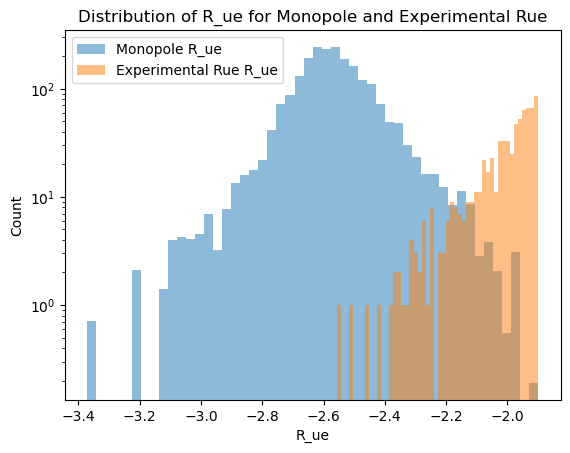

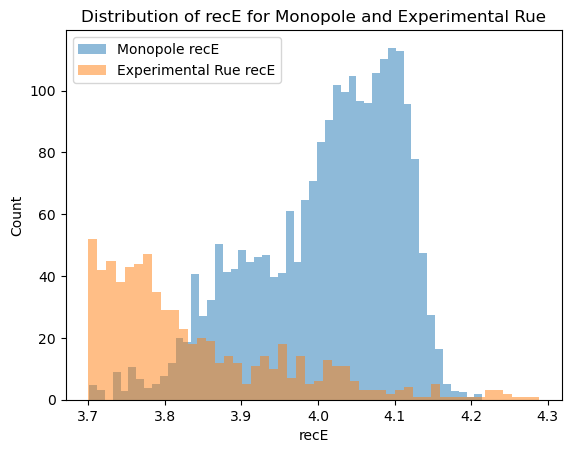

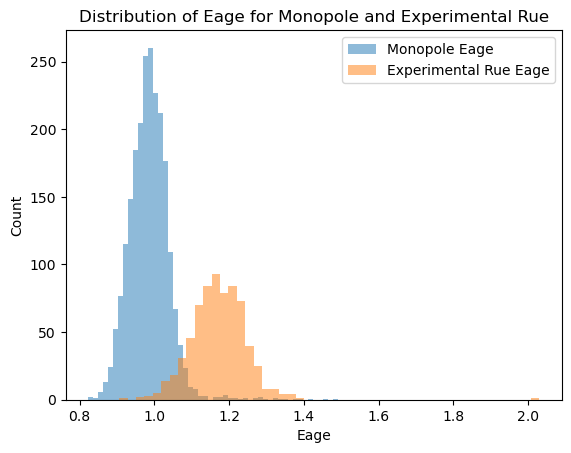

In [12]:
import matplotlib.pyplot as plt
plt.hist(mn_df_large['R_ue'], weights=mn_df_large['weight']*365*86400*3, bins=50, alpha=0.5, label='Monopole R_ue')
plt.hist(exp_muon_Rue_df_large['R_ue'], bins=50, alpha=0.5, label='Experimental Rue R_ue')
plt.xlabel('R_ue')
plt.ylabel('Count')
plt.title('Distribution of R_ue for Monopole and Experimental Rue')
plt.yscale('log')
plt.legend()
plt.show()

plt.hist(mn_df_large['recE'], weights=mn_df_large['weight']*365*86400*3, bins=50, alpha=0.5, label='Monopole recE')
plt.hist(exp_muon_Rue_df_large['recE'], bins=50, alpha=0.5, label='Experimental Rue recE')
plt.xlabel('recE')
plt.ylabel('Count')
plt.title('Distribution of recE for Monopole and Experimental Rue')
# plt.yscale('log')
plt.legend()
plt.show()

plt.hist(mn_df_large['Eage'], weights=mn_df_large['weight']*365*86400*3, bins=50, alpha=0.5, label='Monopole Eage')
plt.hist(exp_muon_Rue_df_large['Eage'], bins=50, alpha=0.5, label='Experimental Rue Eage')
plt.xlabel('Eage')
plt.ylabel('Count')
plt.title('Distribution of Eage for Monopole and Experimental Rue')
# plt.yscale('log')
plt.legend()
plt.show()

Experimental Rue SR count: 103, CR count: 586


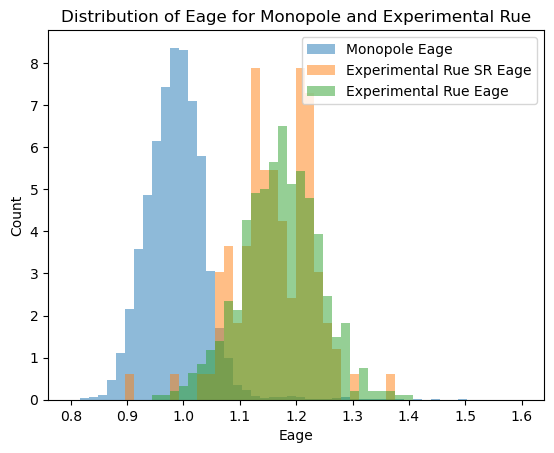

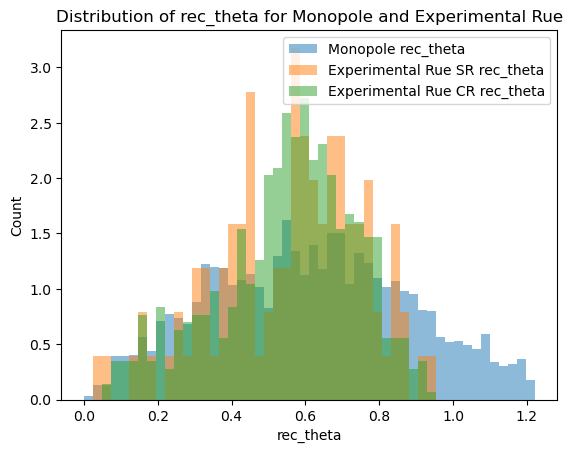

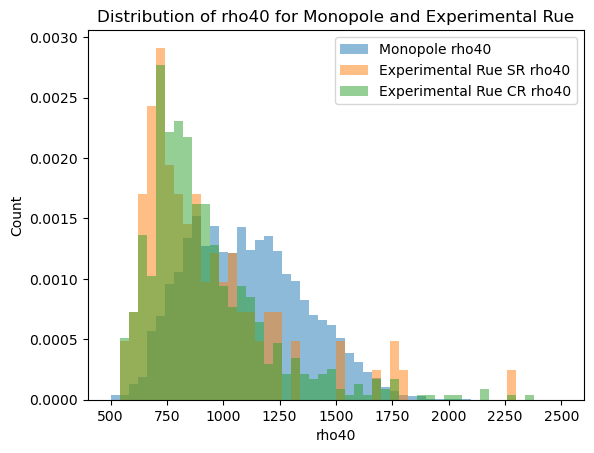

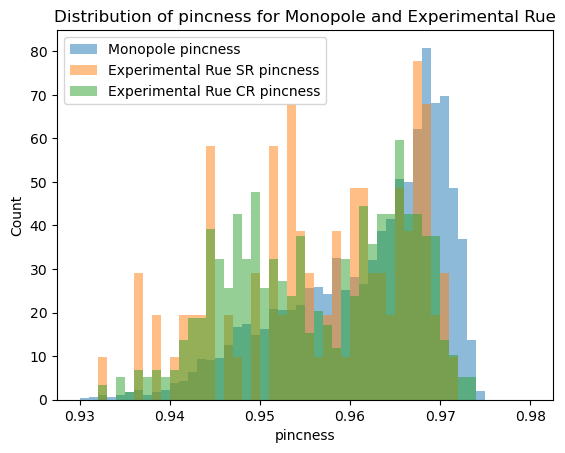

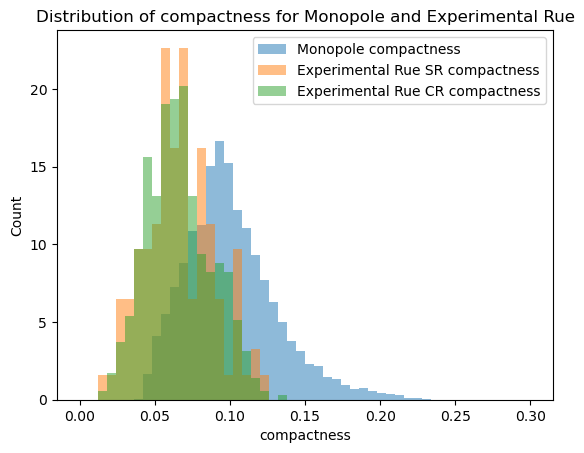

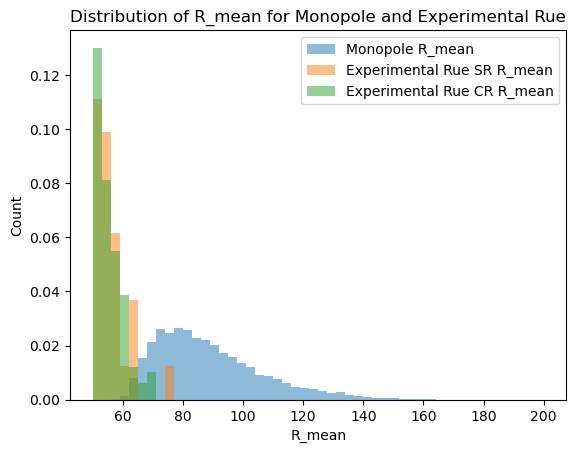

In [21]:
exp_temp_df = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue']>-2.1) & (exp_muon_Rue_df_large['R_ue']<-1.9)]
exp_SR_df = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue']<-2.1)]
print(f"Experimental Rue SR count: {len(exp_SR_df)}, CR count: {len(exp_temp_df)}")
Eage_range = (0.8, 1.6)
plt.hist(mn_df_large['Eage'], weights=mn_df_large['weight']*365*86400*3, range=Eage_range, density=True, bins=50, alpha=0.5, label='Monopole Eage')
plt.hist(exp_SR_df['Eage'], range=Eage_range, bins=50, alpha=0.5, density=True, label='Experimental Rue SR Eage')
plt.hist(exp_temp_df['Eage'], range=Eage_range, bins=50, alpha=0.5, density=True, label='Experimental Rue Eage')
plt.xlabel('Eage')
plt.ylabel('Count')
plt.title('Distribution of Eage for Monopole and Experimental Rue')
# plt.yscale('log')
plt.legend()
plt.show()

params_dicts = {
    "rec_theta": (0, 70/180*np.pi),
    "rho40": (500, 2500),
    "pincness": (0.93, 0.98),
    "compactness": (0., 0.3),
    "R_mean": (50, 200),
}

for param, (low, high) in params_dicts.items():
    plt.hist(mn_df_large[param], weights=mn_df_large['weight']*365*86400*3, density=True, bins=50, range=(low, high), alpha=0.5, label=f'Monopole {param}')
    plt.hist(exp_SR_df[param], bins=50, density=True, range=(low, high), alpha=0.5, label=f'Experimental Rue SR {param}')
    plt.hist(exp_temp_df[param], bins=50, density=True, range=(low, high), alpha=0.5, label=f'Experimental Rue CR {param}')
    plt.xlabel(param)
    plt.ylabel('Count')
    plt.title(f'Distribution of {param} for Monopole and Experimental Rue')
    # plt.yscale('log')
    plt.legend()
    plt.show()